### Baseline Model: Linear Regression

In [1]:
# Importing python libraries
import os
import requests
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score
)

In [2]:
# Download Breast Cancer Wisconsin (Diagnostic) dataset
zip_url = "https://archive.ics.uci.edu/static/public/17/breast+cancer+wisconsin+diagnostic.zip"

# Create data directory
extract_path = "data"
os.makedirs(extract_path, exist_ok=True)

# Download the zip file
zip_path = os.path.join(extract_path, "breast_cancer.zip")

response = requests.get(zip_url)
response.raise_for_status()  # Ensure download worked

with open(zip_path, "wb") as f:
    f.write(response.content)

# Extract contents
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Download and extraction completed.")

# Column names
columns = [
    "id",
    "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

# Load dataset
df = pd.read_csv(os.path.join(extract_path, "wdbc.data"), header=None, names=columns)

# Quick check
df.head()

Download and extraction completed.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Dataset summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [4]:
# Summary statistics
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [5]:
# Suppress sklearn warnings (clean output)
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [6]:
# Prepare Data
def prepare_data(df):
    df_model = df.drop(columns=["id"]).copy()
    df_model["diagnosis"] = df_model["diagnosis"].map({"M": 1, "B": 0})
    
    X = df_model.drop(columns=["diagnosis"])
    y = df_model["diagnosis"]
    
    return train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

In [7]:
# Evaluate Logistic Regression
def evaluate_logistic_regression(X_train, X_test, y_train, y_test, penalty_type="l2"):
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty=penalty_type,
            solver="liblinear",
            max_iter=1000,
            random_state=42
        ))
    ])
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    metrics = {
        "Model": "L2" if penalty_type == "l2" else "L1",
        "Accuracy": round(accuracy, 4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "AUC-ROC": round(auc, 4),
        "ConfusionMatrix": np.array([[tn, fp],[fn, tp]])
    }
    
    return model, metrics

In [8]:
# Run Baseline Comparison
def run_baseline_comparison(df):
    X_train, X_test, y_train, y_test = prepare_data(df)
    
    results = []
    models = {}
    
    for penalty in ["l1", "l2"]:
        model, metrics = evaluate_logistic_regression(
            X_train, X_test, y_train, y_test, penalty
        )
        results.append({k: metrics[k] for k in metrics if k != "ConfusionMatrix"})
        models[metrics["Model"]] = metrics["ConfusionMatrix"]
    
    results_df = pd.DataFrame(results).set_index("Model")
    return results_df, models

In [10]:
# Execute
results_table, confusion_matrices = run_baseline_comparison(df)

print("\nBaseline Logistic Regression Comparison\n")
print(results_table)


Baseline Logistic Regression Comparison

       Accuracy  Sensitivity  Specificity  AUC-ROC
Model                                             
L1       0.9737       0.9524       0.9861   0.9964
L2       0.9737       0.9524       0.9861   0.9960


In [11]:
# Save results to CSV
results_table.to_csv("baseline_results.csv")

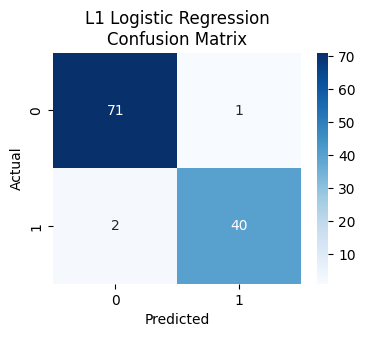

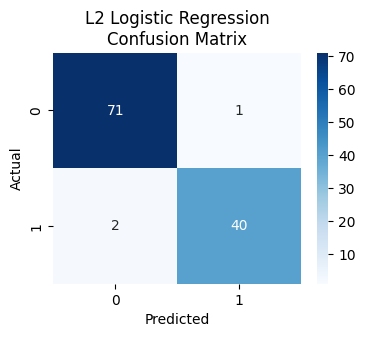

In [12]:
# Plot Confusion Matrices
for model_name, cm in confusion_matrices.items():
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Logistic Regression\nConfusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()